In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import sys
sys.path.append('../')
import analysis_utils as utils

In [2]:
params = {'figure.figsize': (6, 5),
            # 'axes.prop_cycle': default_cycler,
            'axes.titlesize': 14,
            'legend.fontsize': 12,
            'axes.labelsize': 14,
            'axes.titlesize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'xtick.direction': 'in',
            'ytick.direction': 'in',
            'xtick.top': True,
            'ytick.right': True
            }
plt.rcParams.update(params)

In [3]:
def get_random_q_samples(qq, drdq, rr):
    norm_factor = np.trapz(drdq, qq)

    f_drdq_norm = drdq / norm_factor    # PDF of q
    cumsum = np.cumsum(f_drdq_norm)
    Fc_drdq_norm = cumsum / cumsum[-1]  # CDF of q

    qq_sampled = np.interp(rr, Fc_drdq_norm, qq, left=0, right=0)
    return qq_sampled, norm_factor
    
def get_drdqz(qq, drdq):
    ret = np.empty_like(drdq)
    drdq_iso = drdq / (4 * np.pi * qq**2)

    for i, q in enumerate(qq):
        xx = qq[qq >= q]
        integrand = drdq_iso[qq >= q]

        # Another factor of two because we want rate
        # for both +z and -z
        ret[i] = 2 * 2 * np.pi * np.trapz(integrand*xx, xx)

    return ret

In [4]:
R_um = 0.083
mphi = 1
data_dir = f'/home/yt388/palmer_scratch/data/dm_rate/mphi_{mphi:.0e}'

mx_list_coarse = np.logspace(-1, 4, 77)
alpha_list_coarse = np.logspace(-7, -3, 79)

In [84]:
mx = mx_list_coarse[36]
alpha = alpha_list_coarse[14]
mphi = 1

file = f'{data_dir}/drdq_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'
drdq_npz = np.load(file)

qq = drdq_npz['q_kev']
drdq = drdq_npz['drdq_hz_kev']

In [116]:
def smear_drdqz_gauss(qq, drdqz, sigma_kev=180):
    """Convolve spectrum with a Gaussian kernel"""
    dq = qq[1] - qq[0]
    qq_gauss = np.arange(-1000, 1000, dq)
    gauss_kernel = utils.gauss(qq_gauss, A=1, mu=0, sigma=180)

    # Pad the array to minimize edge effect
    # Pad the first two indices with edge value
    # to get the rising tail when q -> 0
    # then pad with mirror image
    pad_len = gauss_kernel.size
    padded_drdqz = np.pad(drdqz, (2, 0), mode='edge')
    padded_drdqz = np.pad(padded_drdqz, (pad_len-2, 0), mode='reflect')
    padded_drdqz = np.pad(padded_drdqz, (0, pad_len), mode='edge')

    convolved = np.convolve(padded_drdqz, gauss_smearing, mode='valid')
    idx_start = (convolved.size - drdqz.size) // 2
    ret = convolved[idx_start : idx_start + drdqz.size] / np.sum(gauss_smearing)

    return ret

In [117]:
drdqz = get_drdqz(qq, drdq)
drdqz_smeared = smear_drdqz_gauss(qq, drdqz, 180)

0.009789928749471686
0.006848951385379884


(0.0, 20000.0)

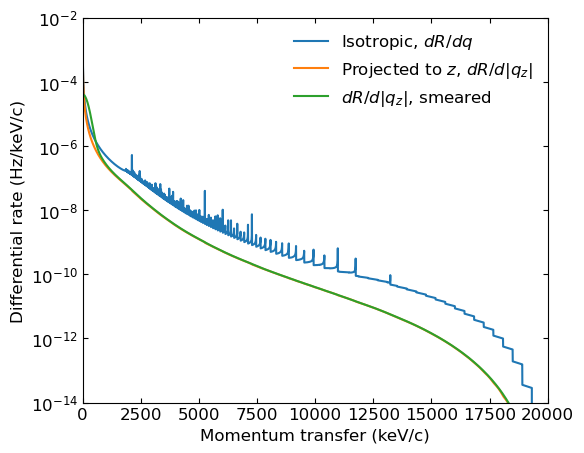

In [118]:
print(np.trapz(drdq, qq))
print(np.trapz(drdqz, qq))

plt.plot(qq, drdq, label='Isotropic, $dR/dq$')
plt.plot(qq, drdqz, label='Projected to $z$, $dR/d|q_z|$')
plt.plot(qq, drdqz_smeared, label='$dR/d|q_z|$, smeared')
plt.yscale('log')

plt.legend(frameon=False)
plt.xlabel('Momentum transfer (keV/c)', fontsize=12)
plt.ylabel('Differential rate (Hz/keV/c)', fontsize=12)

plt.ylim(1e-14, 1e-2)
plt.xlim(0, 20000)

In [32]:
qmax = max(50 * (_qq[np.nonzero(_drdq_smoothed > 0)[0][-1]] // 50 + 2), 10000)
bins_sample = np.arange(0, qmax, 50)
bc = 0.5 * (bins_sample[1:] + bins_sample[:-1])

n_mc = int(1e8)
sigma_gaus = 180
rng = np.random.default_rng()

rr = rng.uniform(0, 1, n_mc)
uu = rng.uniform(-1, 1, n_mc)
phiphi = rng.uniform(0, 2*np.pi, n_mc)
noise_gaussian = rng.normal(0, sigma_gaus, n_mc)

qq_sampled, norm = get_random_q_samples(qq, drdq, rr)

hh, be   = np.histogram(np.abs(qq_sampled), bins=np.arange(0, qmax, 50), density=True)
hhx, be  = np.histogram(np.abs(qq_sampled * np.sqrt(1 - uu**2) * np.cos(phiphi)), bins=np.arange(0, qmax, 50), density=True)
hhy, be  = np.histogram(np.abs(qq_sampled * np.sqrt(1 - uu**2) * np.sin(phiphi)), bins=np.arange(0, qmax, 50), density=True)
hhz, be  = np.histogram(np.abs(qq_sampled * uu), bins=np.arange(0, qmax, 50), density=True)
hhzn, be = np.histogram(np.abs(qq_sampled * uu + noise_gaussian), bins=bins_sample, density=True)


(1e-10, 0.001)

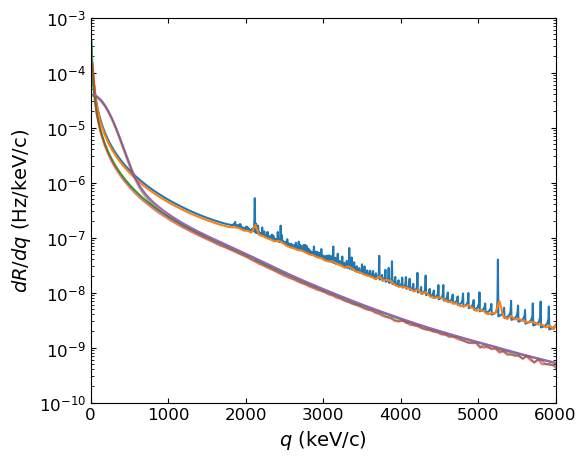

In [126]:
bc = 0.5 * (bins_sample[1:] + bins_sample[:-1])

plt.plot(qq, drdq)
plt.plot(bc, hh*norm)

plt.plot(qq, drdqz)
# plt.plot(bc, hhx*norm, alpha=0.4)
# plt.plot(bc, hhy*norm, alpha=0.4)
plt.plot(bc, hhz*norm, alpha=0.6)

plt.plot(qq, drdqz_smeared)
plt.plot(bc, hhzn*norm, alpha=0.6)

plt.yscale('log')
plt.xlabel('$q$ (keV/c)')
plt.ylabel('$dR/dq$ (Hz/keV/c)')

plt.xlim(0, 6000)
plt.ylim(1e-10, 1e-3)
